In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import matplotlib.pyplot as plt
from scripts.hamiltonian import *

In [45]:
t = 1
mu = -2. * t
gap_p= cp.array([0.1, 0.1])
gap_0 = 0.1
X,Y = 10,100
lattice = Lattice(X, Y, pbc_x=False, pbc_y=False)
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_0 * s2
    block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)
    H.set_gap(gap_0,i)

    
for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j),gap_p = gap_p)
    block[0:2, 2:4] = gap_ij
    block[2:4, 0:2] = -gap_ij.T.conj()

    H.set_block(i,j, block)


energies = cp.linspace(-3,6,500) 
dos = H.dos(energies, eta=0.1, drop_matrix=False)

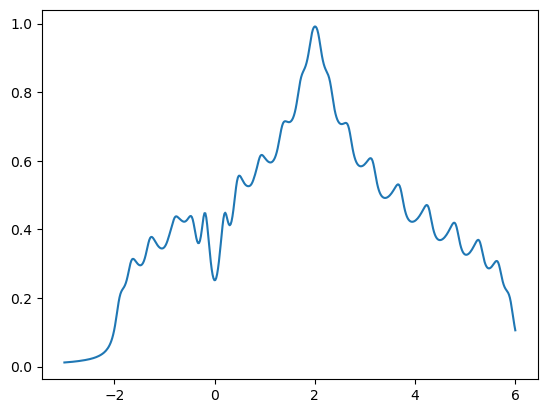

In [47]:
plt.plot(cp.asnumpy(energies),cp.asnumpy(dos))

In [ ]:
def neighbor_maps_square(lattice: SquareLattice):
    X, Y = lattice.X, lattice.Y
    N = lattice.num_sites

    nbr = {"+x": -cp.ones(N, dtype=int),
           "-x": -cp.ones(N, dtype=int),
           "+y": -cp.ones(N, dtype=int),
           "-y": -cp.ones(N, dtype=int)}

    for y in range(Y):
        for x in range(X):
            i = y * X + x
            # +x
            if x < X-1:
                nbr["+x"][i] = i + 1
            elif lattice.pbc_x and X > 2:
                nbr["+x"][i] = y * X

            # -x
            if x > 0:
                nbr["-x"][i] = i - 1
            elif lattice.pbc_x and X > 2:
                nbr["-x"][i] = y * X + (X-1)

            # +y
            if y < Y-1:
                nbr["+y"][i] = (y+1) * X + x
            elif lattice.pbc_y and Y > 2:
                nbr["+y"][i] = x

            # -y
            if y > 0:
                nbr["-y"][i] = (y-1) * X + x
            elif lattice.pbc_y and Y > 2:
                nbr["-y"][i] = (Y-1) * X + x

    return nbr


In [ ]:
def gather_at(j_idx, arr):
    # arr is (Neig,N). Return (Neig,N) with invalid neighbors zeroed.
    valid = (j_idx >= 0)
    j_safe = cp.where(valid, j_idx, 0)
    out = arr[:, j_safe]
    return out * valid[cp.newaxis, :]  # zero invalid sites

def correlators(H, T):

    nbr = neighbor_maps_square(H.lattice)
    F0 = cp.zeros_like(H.gap_0)
    F = {}          # singlet-like (up at i, down at j)
    Fuu = {}        # triplet component uu
    Fdd = {}        # triplet component dd


    eigval, eigvec = H.diagonalize(drop_matrix=False)
    eigvec = eigvec[:, eigval >= 0]
    eigval = eigval[eigval >= 0]
    eigvec = eigvec.T.reshape((eigval.size, -1, 4))

    f = fermi_dirac(eigval, T)          # (Neig,)
    u_up = eigvec[:, :, 0]              # (Neig, Nsites)
    u_dn = eigvec[:, :, 1]
    v_up = eigvec[:, :, 2]
    v_dn = eigvec[:, :, 3]

    F0 = (
        cp.einsum('ni,ni,n->i', u_dn, cp.conj(v_up), f) +
        cp.einsum('ni,ni,n->i', u_up, cp.conj(v_dn), (1-f))
    )
    
    for d in ["+x", "-x", "+y", "-y"]:
        j = nbr[d]

        vdn_j = gather_at(j, v_dn)
        udn_j = gather_at(j, u_dn)
        vup_j = gather_at(j, v_up)
        uup_j = gather_at(j, u_up)

        F[d] = (
            cp.einsum('ni,ni,n->i', u_up, cp.conj(vdn_j), (1 - f)) +
            cp.einsum('ni,ni,n->i', v_up, cp.conj(udn_j), f)
        )
        # Eqn 2: F_{i,↑↑}^d
        Fuu[d] = (
            cp.einsum('ni,ni,n->i', u_up, cp.conj(vup_j), (1 - f)) +
            cp.einsum('ni,ni,n->i', v_up, cp.conj(uup_j), f)
        )
        # Eqn 3: F_{i,↓↓}^d
        Fdd[d] = (
            cp.einsum('ni,ni,n->i', u_dn, cp.conj(vdn_j), (1 - f)) +
            cp.einsum('ni,ni,n->i', v_dn, cp.conj(udn_j), f)
        )
    return F0, F, Fuu, Fdd

In [4]:
def bdg_self_consistency(H, U, V, V_prime, 
                         T, max_iter=100,
                         atol=1e-6, rtol=1e-4,
                         with_corr = False):
        flag = False
        num_sites = H.lattice.num_sites

        for iteration in range(max_iter):
            F0, F, Fuu, Fdd = correlators(H, T)
            gap_0 = -U * F0
            gap_s = V * (F["+x"] + F["-x"] + F["+y"] + F["-y"])/4
            gap_d = V * (F["+x"] + F["-x"] - F["+y"] - F["-y"])/4
            gap_px = V * (F["+x"] - F["-x"])/2
            gap_py = V * (F["+y"] - F["-y"])/2
            gap_px_uu = V_prime * (Fuu["+x"] - Fuu["-x"])/2
            gap_py_uu = V_prime * (Fuu["+y"] - Fuu["-y"])/2
            gap_px_dd = V_prime * (Fdd["+x"] - Fdd["-x"])/2
            gap_py_dd = V_prime * (Fdd["+y"] - Fdd["-y"])/2
            
            for i in range(num_sites):
                # indices for the 4x4 block of site i
                sl = slice(4*i, 4*(i+1))
                H.matrix[sl, sl][:2, 2:] = -1j * gap_0[i] * s2
                H.matrix[sl, sl][2:, :2] = (-1j * gap_0[i] * s2).conj().T

            for i, j in H.lattice.edges:
                sli = slice(4*i, 4*(i+1))
                slj = slice(4*j, 4*(j+1))
                gap_p = cp.array([(gap_px[i]-gap_px[j])/2,
                                  (gap_py[i]-gap_py[j])/2])
                gap_p_uu = cp.array([(gap_px_uu[i]-gap_px_uu[j])/2,
                                     (gap_py_uu[i] - gap_py_uu[j])/2])
                gap_p_dd = cp.array([(gap_px_dd[i] - gap_px_dd[j])/2,
                                     (gap_py_dd[i] - gap_py_dd[j])/2])

                gap_ij = unconventional_gap(H.lattice.get_disp(i, j), gap_s=(gap_s[i]+gap_s[j])/2, 
                                            gap_d=(gap_d[i] + gap_d[j])/2, gap_p=gap_p,
                                            gap_p_dd=gap_p_dd, gap_p_uu=gap_p_uu)
                H.matrix[sli, slj][:2, 2:] =  gap_ij
                H.matrix[sli, slj][2:, :2] = -gap_ij.T.conj()

            if (cp.max(cp.abs(gap_0 - H.gap)) < atol + rtol * cp.max(cp.abs(gap_0))
                and cp.max(cp.abs(gap_s - H.gap_s)) < atol + rtol * cp.max(cp.abs(gap_s))
                and cp.max(cp.abs(gap_d - H.gap_d)) < atol + rtol * cp.max(cp.abs(gap_d))
                and cp.max(cp.abs(gap_px - H.gap_px)) < atol + rtol * cp.max(cp.abs(gap_px))
                and cp.max(cp.abs(gap_py - H.gap_py)) < atol + rtol * cp.max(cp.abs(gap_py))
                and cp.max(cp.abs(gap_px_uu - H.gap_px_uu)) < atol + rtol * cp.max(cp.abs(gap_px_uu))
                and cp.max(cp.abs(gap_py_uu - H.gap_py_uu)) < atol + rtol * cp.max(cp.abs(gap_py_uu))
                and cp.max(cp.abs(gap_px_dd - H.gap_px_dd)) < atol + rtol * cp.max(cp.abs(gap_px_dd))
                and cp.max(cp.abs(gap_py_dd - H.gap_py_dd)) < atol + rtol * cp.max(cp.abs(gap_py_dd))
                ):
                print(f"Converged after {iteration+1} iterations.")
                H.gap = gap_0
                H.gap_s = gap_s
                H.gap_d = gap_d
                H.gap_px = gap_px
                H.gap_py = gap_py
                H.gap_px_uu = gap_px_uu
                H.gap_py_uu = gap_py_uu
                H.gap_px_dd = gap_px_dd
                H.gap_py_dd = gap_py_dd
                flag = True
                break
            H.gap = gap_0
            H.gap_s = gap_s
            H.gap_d = gap_d
            H.gap_px = gap_px
            H.gap_py = gap_py
            H.gap_px_uu = gap_px_uu
            H.gap_py_uu = gap_py_uu
            H.gap_px_dd = gap_px_dd
            H.gap_py_dd = gap_py_dd

        if not flag:
            print(f"Failed to converge after {iteration+1} iterations")
        if with_corr:
            return F0, F, Fuu, Fdd

In [60]:
t = 1
mu = 0#-1.6 * t
gap_p= cp.array([0., 0.j])
X,Y = 30,40
U = 1.5 * t
V = 2.5 * t
lattice = Lattice(X, Y, pbc_x=False, pbc_y=True)
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    # block[:2, 2:] = -1j * gap_0 * s2
    # block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)
    # H.set_gap(gap_0,i)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j),gap_s = 0.1)
    block[0:2, 2:4] = gap_ij
    block[2:4, 0:2] = -gap_ij.T.conj()

    H.set_block(i,j, block)
H.gap_s = cp.ones(lattice.num_sites, dtype=cp.complex128)*0.1

F0, F, Fuu, Fdd = bdg_self_consistency(H,U=0,V=V,V_prime=0,T=0, max_iter=100, with_corr=True)

Failed to converge after 100 iterations


In [ ]:
print 

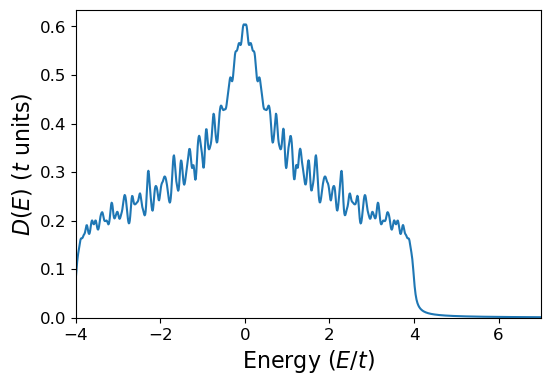

In [62]:
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.05, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

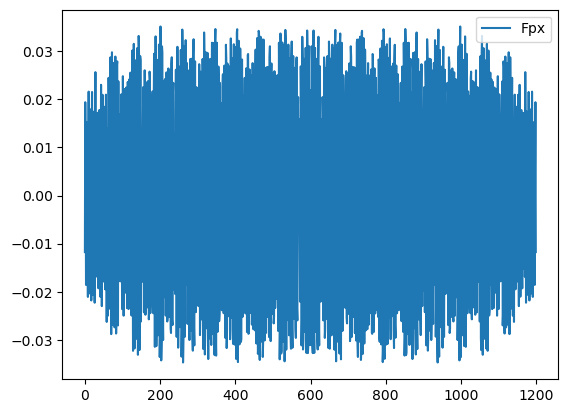

In [64]:
plt.figure()
# for d in ["+x", "-x", "+y", "-y"]:
    # plt.plot(cp.asnumpy(F[]), label=f'F {d}')
# plt.plot(np.real(cp.asnumpy((F['+x']+F['-x'])/2)), label=f'Fpx')
plt.plot(np.real(cp.asnumpy((F['+x']+F['-x']-F['+y']-F['-y'])/4)), label=f'Fpx')
# plt.plot(np.real(cp.asnumpy(F0)), label=f'Fpx')

plt.legend()
plt.show()